In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings

In [150]:
oil = pd.read_csv("http://137.23.24.234/datasets//store-sales-forecasting/oil.csv")
sample_submission = pd.read_csv("http://137.23.24.234/datasets/store-sales-forecasting/sample_submission.csv")
df = pd.read_csv("http://137.23.24.234/datasets/store-sales-forecasting/train.csv")
holidays = pd.read_csv("http://137.23.24.234/datasets/store-sales-forecasting/holidays_events.csv")
# 

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [152]:
df["family"].unique()

<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELECTRONICS',
                    'POULTRY',             'PREPARED FOODS',
                    'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
          

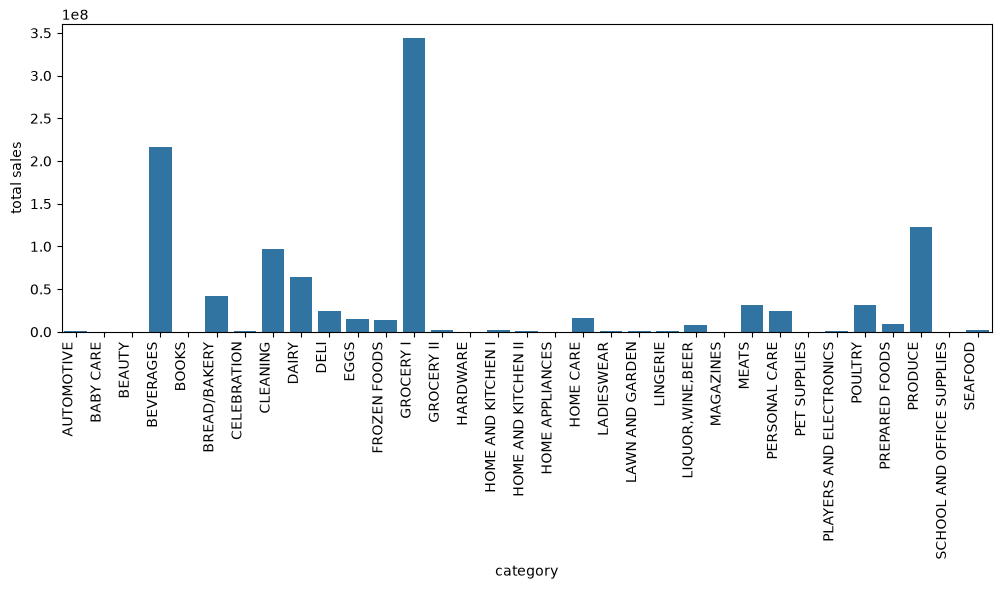

In [153]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=df,
    x="family",
    y="sales",
    estimator="sum",
    errorbar=None
)

plt.xlabel("category")
plt.ylabel("total sales")
plt.xticks(rotation=90, ha="right")

plt.show()

In [154]:
category = "GROCERY I"
store_number = 46

df["date"] = pd.to_datetime(df["date"])

store_cat_sales = df[(df["family"] == category) & (df["store_nbr"] == store_number)]

print(store_cat_sales)

              id       date  store_nbr     family    sales  onpromotion
1332        1332 2013-01-01         46  GROCERY I      0.0            0
3114        3114 2013-01-02         46  GROCERY I  10892.0            0
4896        4896 2013-01-03         46  GROCERY I   6493.0            0
6678        6678 2013-01-04         46  GROCERY I   6499.0            0
8460        8460 2013-01-05         46  GROCERY I  10827.0            0
...          ...        ...        ...        ...      ...          ...
2993310  2993310 2017-08-11         46  GROCERY I   9934.0           41
2995092  2995092 2017-08-12         46  GROCERY I   9218.0           40
2996874  2996874 2017-08-13         46  GROCERY I  10557.0           40
2998656  2998656 2017-08-14         46  GROCERY I   7570.0           39
3000438  3000438 2017-08-15         46  GROCERY I   7222.0           37

[1684 rows x 6 columns]


In [155]:
series = store_cat_sales.set_index("date").sort_index()[["sales", "onpromotion"]]

series = series.asfreq('D').interpolate('time')

print(series)

              sales  onpromotion
date                            
2013-01-01      0.0          0.0
2013-01-02  10892.0          0.0
2013-01-03   6493.0          0.0
2013-01-04   6499.0          0.0
2013-01-05  10827.0          0.0
...             ...          ...
2017-08-11   9934.0         41.0
2017-08-12   9218.0         40.0
2017-08-13  10557.0         40.0
2017-08-14   7570.0         39.0
2017-08-15   7222.0         37.0

[1688 rows x 2 columns]


In [156]:
# save csv file
# summary.to_csv('sales.csv', index=True)

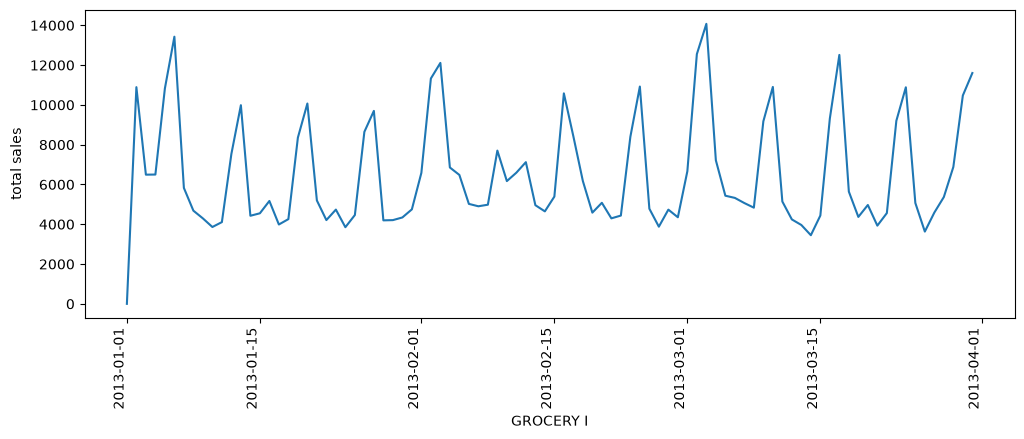

In [157]:
# plot sales data

fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(
    data=series.iloc[:90],
    x='date',
    y="sales",
)

plt.xlabel(category)
plt.ylabel("total sales")
plt.xticks(rotation=90, ha="right")

plt.show()

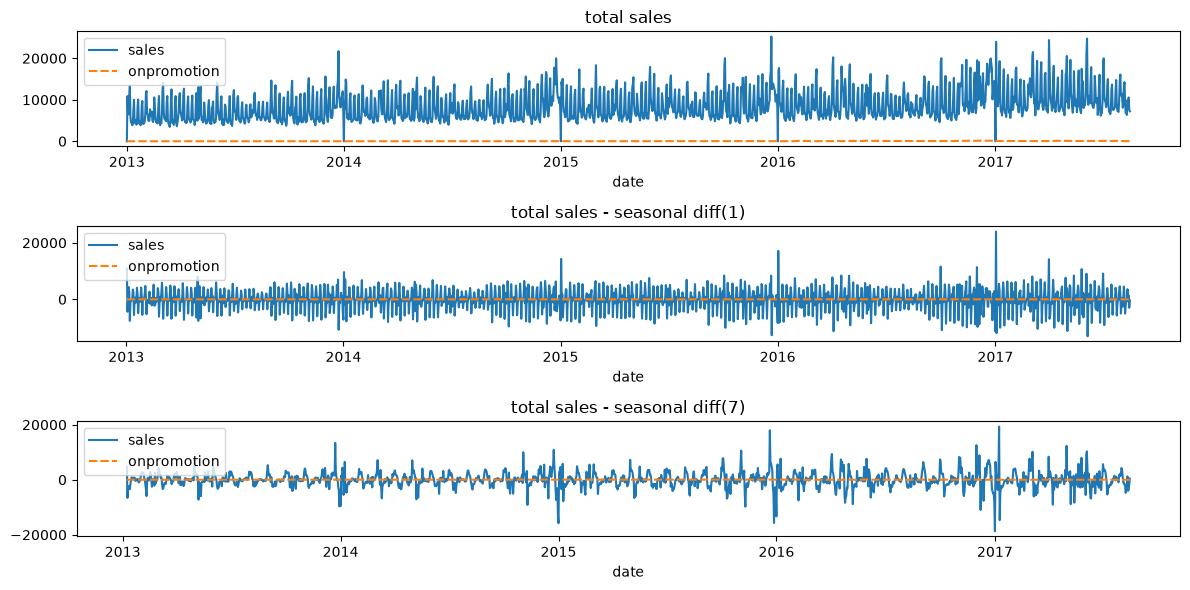

In [158]:
# plot the total sales and difference
fig, ax = plt.subplots(3, 1, figsize=(12, 6))
sns.lineplot(data=series, ax=ax[0])
sns.lineplot(data=series.diff(1), ax=ax[1])
sns.lineplot(data=series.diff(7), ax=ax[2])

ax[0].set_title("total sales")
ax[1].set_title("total sales - seasonal diff(1)")
ax[2].set_title("total sales - seasonal diff(7)")

plt.tight_layout()
plt.show()

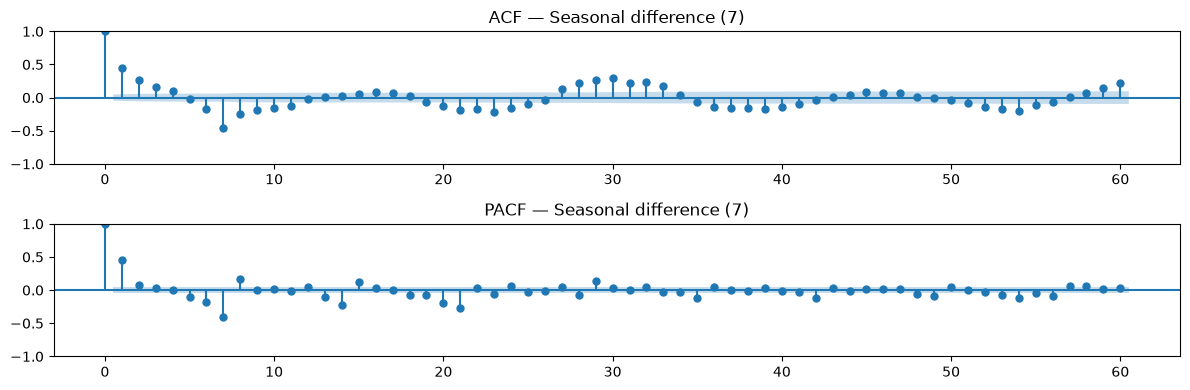

In [159]:
# ACF & PACF ANALYSIS

diffed = series["sales"].diff(7).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
plot_acf(diffed,  lags=60, ax=axes[0], title="ACF — Seasonal difference (7)")
plot_pacf(diffed, lags=60, ax=axes[1], title="PACF — Seasonal difference (7)", method="ywm")
plt.tight_layout()
plt.show()

In [160]:
# @title
# ADF test reports

def adf_report(x, label=""):
    results = adfuller(x.dropna(), autolag="AIC")
    print(f"--- ADF test: {label} ---")
    print(f"ADF statistic: {results[0]:.4f}")
    print(f"p-value: {results[1]:.4f}")
    for k, v in results[4].items():
        print(f"  critical value ({k}): {v:.4f}")
    if results[1] < 0.05:
        print("=> Reject H0: series looks stationary\n")
    else:
        print("=> Fail to reject H0: series looks non-stationary\n")

adf_report(series["sales"], "total_sales")

adf_report(series["sales"].diff(7), "total_sales first difference")

--- ADF test: total_sales ---
ADF statistic: -4.3706
p-value: 0.0003
  critical value (1%): -3.4343
  critical value (5%): -2.8633
  critical value (10%): -2.5677
=> Reject H0: series looks stationary

--- ADF test: total_sales first difference ---
ADF statistic: -13.5941
p-value: 0.0000
  critical value (1%): -3.4343
  critical value (5%): -2.8633
  critical value (10%): -2.5677
=> Reject H0: series looks stationary



<Axes: title={'center': 'onpromotion'}, xlabel='date'>

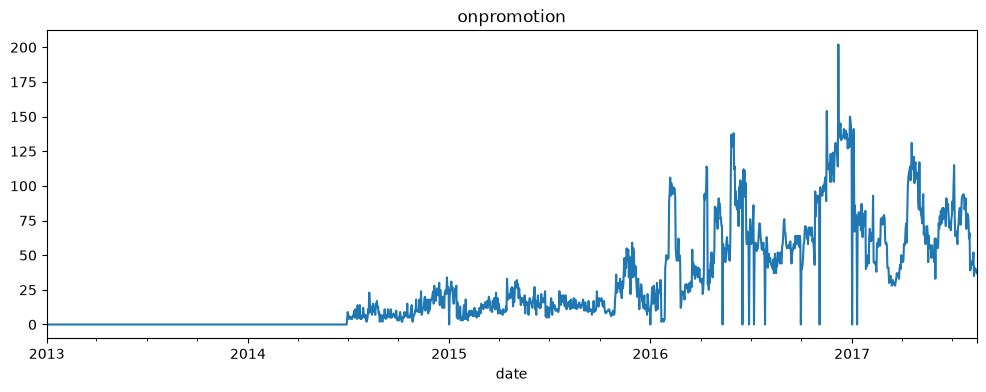

In [161]:
series["onpromotion"].plot(figsize=(12, 4), title="onpromotion")

In [162]:
series["onpromotion"].info


<bound method Series.info of date
2013-01-01     0.0
2013-01-02     0.0
2013-01-03     0.0
2013-01-04     0.0
2013-01-05     0.0
              ... 
2017-08-11    41.0
2017-08-12    40.0
2017-08-13    40.0
2017-08-14    39.0
2017-08-15    37.0
Freq: D, Name: onpromotion, Length: 1688, dtype: float64>

In [169]:
# SARIMA model 
test_size = 60

# log transformation for large sales number
series[series["sales"] == 0] = np.nan 
series.loc[series["onpromotion"].isna(), "onpromotion"] = 0

series["log_sales"] = np.log(series["sales"] + 1)
# series["scale_sales"] = series["sales"] / 1000

train = series.iloc[: -test_size].copy()
test = series.iloc[-test_size:].copy()

model = SARIMAX(
train["log_sales"],
order=(1, 1, 1),
seasonal_order=(0, 1, 1, 7),
enforce_stationarity=False,
enforce_invertibility=False,
exog=train["onpromotion"]
)

results = model.fit()

print(results.summary())

# Forecast and invert log transformation back to original scale
log_forecast = results.forecast(steps=test_size, exog=test["onpromotion"])
forecast = np.expm1(log_forecast)  # Inverts np.log1p



                                     SARIMAX Results                                     
Dep. Variable:                         log_sales   No. Observations:                 1628
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood                 592.420
Date:                           Wed, 05 Aug 2026   AIC                          -1174.840
Time:                                   12:59:53   BIC                          -1147.917
Sample:                               01-01-2013   HQIC                         -1164.846
                                    - 06-16-2017                                         
Covariance Type:                             opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
onpromotion     0.0011      0.000      3.161      0.002       0.000       0.002
ar.L1           0.6098      0.017     36

In [ ]:
# --- 1. Generate Forecasts for the test set---
# exog features ('onpromotion') for the test horizon
test_exog = test[["onpromotion"]]

forecast_object = results.get_forecast(steps=len(test), exog=test_exog)
log_forecast = forecast_object.predicted_mean
confidence_int_log = forecast_object.conf_int()

# --- 2. Invert Log Transformation Back to Original Scale ---
# Using np.expm1 to match np.log1p (expm1(x) = exp(x) - 1)
y_pred = np.expm1(log_forecast)

# Convert prediction interval back to original scale
lower_bound = np.expm1(confidence_int_log.iloc[:, 0])
upper_bound = np.expm1(confidence_int_log.iloc[:, 1])

# Clip bounds and predictions at zero to prevent impossible negative sales
y_pred = np.maximum(y_pred, 0)
lower_bound = np.maximum(lower_bound, 0)

# --- 3. Compute Accuracy Metrics on Real Sales Scale ---
y_true = test["sales"]

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print(f"==========================================")
print(f" Model Evaluation: SARIMAX(1,1,1)(0,1,1,7)")
print(f" Forecast Horizon: {len(test)} days")
print(f"==========================================")
print(f" MAE  : {mae:.2f}")
print(f" RMSE : {rmse:.2f}")
print(f"==========================================")

# Run this snippet to compute relative performance
mean_sales = test["sales"].mean()
mape = np.mean(np.abs((test["sales"] - y_pred) / test["sales"])) * 100
nrmse = (rmse / mean_sales) * 100

print(f"Average Daily Sales: {mean_sales:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Normalized RMSE (NRMSE): {nrmse:.2f}%")

 Model Evaluation: SARIMAX(1,1,1)(0,1,1,7)
 Forecast Horizon: 60 days
 MAE  : 1908.15
 RMSE : 2334.27
Average Daily Sales: 10081.98
Mean Absolute Percentage Error (MAPE): 19.81%
Normalized RMSE (NRMSE): 23.15%


In [171]:
# Run this snippet to compute relative performance
mean_sales = test["sales"].mean()
mape = np.mean(np.abs((test["sales"] - y_pred) / test["sales"])) * 100
nrmse = (rmse / mean_sales) * 100

print(f"Average Daily Sales: {mean_sales:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Normalized RMSE (NRMSE): {nrmse:.2f}%")

Average Daily Sales: 10081.98
Mean Absolute Percentage Error (MAPE): 19.81%
Normalized RMSE (NRMSE): 23.15%


--- Model Evaluation (Original Scale) ---
MAE  : 1469.73
RMSE : 1824.03


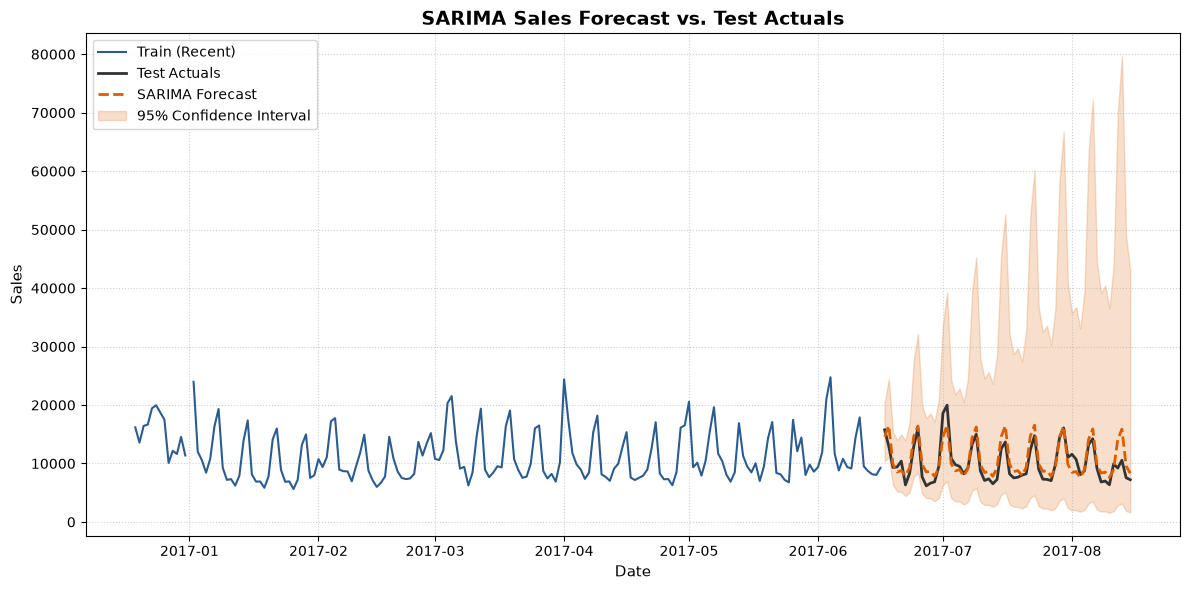

In [ ]:


# --- 1. Get Forecast and Confidence Intervals on Log Scale ---
forecast_object = results.get_forecast(steps=test_size, exog=test["onpromotion"])
log_forecast = forecast_object.predicted_mean
confidence_int_log = forecast_object.conf_int()

# --- 2. Invert Log Transformation Back to Original Scale ---
# Using np.expm1 to match np.log1p (expm1(x) = exp(x) - 1)
forecast_actual_scale = np.expm1(log_forecast)

confidence_int_actual = np.expm1(confidence_int_log)
lower_bound = confidence_int_actual.iloc[:, 0]
upper_bound = confidence_int_actual.iloc[:, 1]

# Ensure no negative sales values in bounds after inversion
lower_bound = np.maximum(lower_bound, 0)
forecast_actual_scale = np.maximum(forecast_actual_scale, 0)

# --- 3. Compute Metrics on Original Sales Scale ---
y_true = test["sales"]
y_pred = forecast_actual_scale

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print(f"--- Model Evaluation (Original Scale) ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# --- 4. Plot Results ---
plt.figure(figsize=(12, 6))

# Plot recent training data (e.g., last 180 days for context)
plt.plot(
    train.index[-180:],
    train["sales"].tail(180),
    label="Train (Recent)",
    color="#2b5c8f",
)

# Plot actual test sales
plt.plot(test.index, y_true, label="Test Actuals", color="#333333", linewidth=2)

# Plot point forecast
plt.plot(
    test.index,
    y_pred,
    label="SARIMA Forecast",
    color="#d95f02",
    linewidth=2,
    linestyle="--",
)

# Plot confidence interval (shaded region)
plt.fill_between(
    test.index,
    lower_bound,
    upper_bound,
    color="#d95f02",
    alpha=0.2,
    label="95% Confidence Interval",
)

plt.title("SARIMA Sales Forecast vs. Test Actuals", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=11)
plt.ylabel("Sales", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

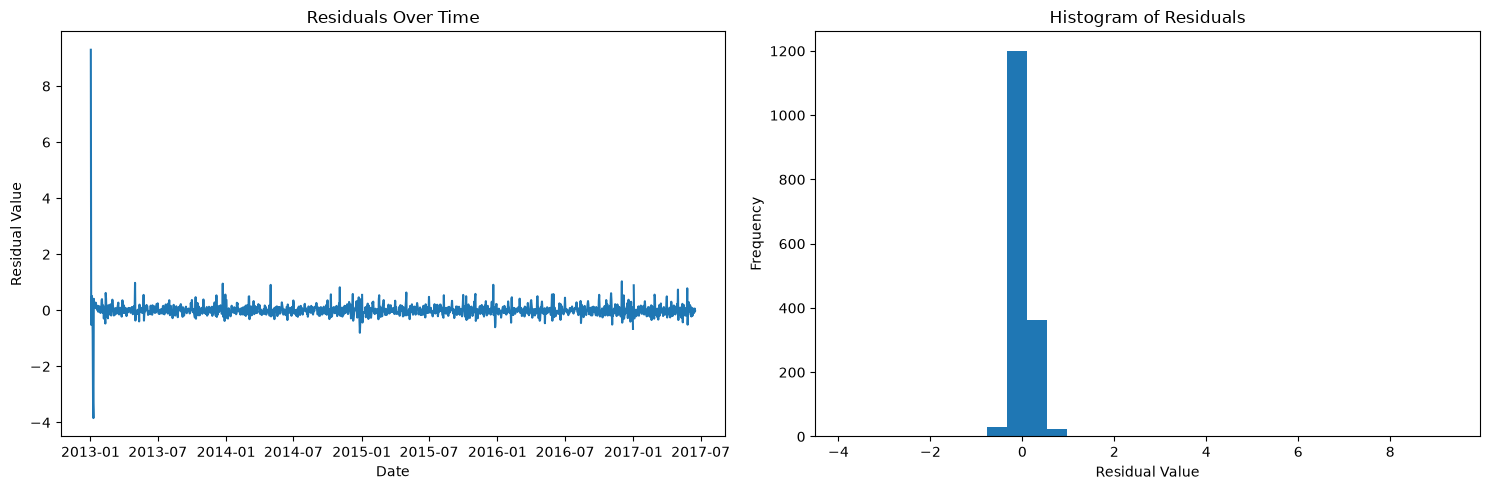

In [165]:
# Get the residuals from the model results
residuals = pd.DataFrame(results.resid)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot the residuals over time
axes[0].plot(residuals)
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual Value')

# Plot a histogram of the residuals
axes[1].hist(residuals, bins=30)
axes[1].set_title('Histogram of Residuals')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [166]:
resid = results.resid
resid.abs().nlargest(10)     # dates of the remaining worst residuals

date
2013-01-02    9.295876
2013-01-09    3.844894
2013-01-08    3.314656
2016-12-01    1.033544
2013-05-01    0.978911
2013-12-23    0.951912
2015-12-21    0.910533
2014-05-01    0.907285
2017-01-02    0.892253
2013-01-07    0.834743
dtype: float64

In [167]:
series["sales"].head(15)     # what do the first days of Jan 2013 look like?

date
2013-01-01        NaN
2013-01-02    10892.0
2013-01-03     6493.0
2013-01-04     6499.0
2013-01-05    10827.0
2013-01-06    13428.0
2013-01-07     5827.0
2013-01-08     4683.0
2013-01-09     4295.0
2013-01-10     3862.0
2013-01-11     4108.0
2013-01-12     7535.0
2013-01-13     9985.0
2013-01-14     4427.0
2013-01-15     4551.0
Freq: D, Name: sales, dtype: float64

In [ ]:
"""
Grid search over SARIMA orders for daily store-category sales.

The DIFFERENCING is fixed at what the diagnostics established and is NOT searched:
    d = 0    (seasonal diff already made the series stationary; ADF confirmed)
    D = 1, s = 7   (weekly seasonality)
Searching d/D as well tends to just rediscover this and wastes time, so we
grid ONLY the AR/MA orders (p, q, P, Q).

Each candidate is:
    - fit on log(sales) with the same Fourier + holiday regressors as the main model
    - scored by AICc (in-sample, penalised for parameters)
    - AND evaluated on a 28-day holdout (out-of-sample MAPE / RMSE)
Ranking by AICc is standard; the holdout column is there to catch models that
win on AICc but generalise badly. Trust a model only when both agree.

Set USE_ROLLING = True for a more robust multi-window backtest (slower).
"""

import warnings
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")           # silence convergence chatter during search

# ----------------------------------------------------------------------
# config
# ----------------------------------------------------------------------
CSV_PATH  = "output.csv"
SEASON    = 7                                # weekly
D_FIXED   = 1                               # non-seasonal differencing (fixed)
DD_FIXED  = 1                                # seasonal differencing (fixed)
FOURIER_K = 4
HORIZON   = 28

# search ranges  (edit to widen/narrow the grid)
P_RANGE = range(0, 4)     # non-seasonal AR
Q_RANGE = range(0, 3)     # non-seasonal MA
PP_RANGE = range(0, 2)    # seasonal AR
QQ_RANGE = range(0, 2)    # seasonal MA

USE_ROLLING   = False     # True -> average MAPE over several windows (slower)
ROLLING_FOLDS = 4


# ----------------------------------------------------------------------
# data + regressors  (identical pipeline to the main model)
# ----------------------------------------------------------------------
def load_series(path):
    s = (pd.read_csv(path, parse_dates=["date"])
           .set_index("date")["total_sales"].sort_index())
    assert s.index.duplicated().sum() == 0, "resolve duplicate dates first"
    return s.asfreq("D").interpolate("time")


def make_exog(index, origin, K=FOURIER_K):
    t = (index - origin).days.values.astype(float)
    cols = {}
    for k in range(1, K + 1):
        cols[f"sin{k}"] = np.sin(2 * np.pi * k * t / 365.25)
        cols[f"cos{k}"] = np.cos(2 * np.pi * k * t / 365.25)
    X = pd.DataFrame(cols, index=index)
    X["newyear"] = ((index.month == 1) & (index.day <= 2)).astype(int)
    X["xmas"]    = ((index.month == 12) & (index.day.isin([24, 25, 26]))).astype(int)
    return X


def aicc(res):
    k, n = res.params.size, res.nobs
    return res.aic + (2 * k * (k + 1)) / max(n - k - 1, 1)


def mape(actual, pred):
    return float((np.abs((actual - pred) / actual)).mean() * 100)


# ----------------------------------------------------------------------
# evaluate one order: returns AICc (full fit) + holdout error
# ----------------------------------------------------------------------
def evaluate(y, X, order, sorder):
    # AICc on the full series
    full = SARIMAX(y, exog=X, order=order, seasonal_order=sorder,
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)
    score = aicc(full)

    # out-of-sample error
    if USE_ROLLING:
        errs = []
        for f in range(ROLLING_FOLDS):
            end = len(y) - (ROLLING_FOLDS - 1 - f) * HORIZON
            y_tr, X_tr = y.iloc[:end - HORIZON], X.iloc[:end - HORIZON]
            y_te, X_te = y.iloc[end - HORIZON:end], X.iloc[end - HORIZON:end]
            r = SARIMAX(y_tr, exog=X_tr, order=order, seasonal_order=sorder,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False)
            pred = np.exp(r.get_forecast(HORIZON, exog=X_te).predicted_mean)
            errs.append(mape(np.exp(y_te), pred))
        oos = float(np.mean(errs))
    else:
        y_tr, X_tr = y.iloc[:-HORIZON], X.iloc[:-HORIZON]
        y_te, X_te = y.iloc[-HORIZON:], X.iloc[-HORIZON:]
        r = SARIMAX(y_tr, exog=X_tr, order=order, seasonal_order=sorder,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        pred = np.exp(r.get_forecast(HORIZON, exog=X_te).predicted_mean)
        oos = mape(np.exp(y_te), pred)

    return score, oos, full.params.size


# ----------------------------------------------------------------------
# main: sweep the grid
# ----------------------------------------------------------------------
def main():
    # s = load_series(CSV_PATH)
    s = series
    y = np.log(s["total_sales"])
    X = make_exog(s.index, origin=s.index[0])

    combos = list(itertools.product(P_RANGE, Q_RANGE, PP_RANGE, QQ_RANGE))
    print(f"Searching {len(combos)} orders "
          f"(d={D_FIXED}, D={DD_FIXED}, s={SEASON}, "
          f"{'rolling' if USE_ROLLING else 'single'} holdout)...\n")

    results = []
    for p, q, P, Q in combos:
        order  = (p, D_FIXED, q)
        sorder = (P, DD_FIXED, Q, SEASON)
        try:
            score, oos, npar = evaluate(y, X, order, sorder)
            results.append((order, sorder, score, oos, npar))
            print(f"  {str(order):10s}{str(sorder):14s}  "
                  f"AICc={score:9.1f}  MAPE={oos:5.2f}%  ({npar} params)")
        except Exception as e:
            print(f"  {str(order):10s}{str(sorder):14s}  FAILED: {str(e)[:40]}")

    if not results:
        print("No models fit successfully."); return

    res_df = (pd.DataFrame(results,
                columns=["order", "seasonal_order", "AICc", "holdout_MAPE", "n_params"])
                .sort_values("AICc").reset_index(drop=True))

    print("\n" + "=" * 60)
    print("TOP 5 BY AICc")
    print(res_df.head(5).to_string(index=False))

    best = res_df.iloc[0]
    print(f"\nBest AICc:        {best['order']}{best['seasonal_order']}  "
          f"(MAPE {best['holdout_MAPE']:.2f}%)")
    best_oos = res_df.sort_values("holdout_MAPE").iloc[0]
    print(f"Best holdout MAPE:{best_oos['order']}{best_oos['seasonal_order']}  "
          f"(MAPE {best_oos['holdout_MAPE']:.2f}%, AICc {best_oos['AICc']:.1f})")
    print("\nPrefer a model where both rankings agree, or the simpler of two "
          "near-ties (fewer params).")

    res_df.to_csv("sarima_gridsearch_results.csv", index=False)
    print("\nsaved sarima_gridsearch_results.csv")


if __name__ == "__main__":
    main()

Searching 48 orders (d=1, D=1, s=7, single holdout)...

  (0, 1, 0) (0, 1, 0, 7)    AICc=   1690.0  MAPE=15.65%  (11 params)
  (0, 1, 0) (0, 1, 1, 7)    AICc=    715.3  MAPE= 8.06%  (12 params)
  (0, 1, 0) (1, 1, 0, 7)    AICc=   1266.1  MAPE= 8.92%  (12 params)
  (0, 1, 0) (1, 1, 1, 7)    AICc=    587.8  MAPE= 8.57%  (13 params)
  (0, 1, 1) (0, 1, 0, 7)    AICc=    484.5  MAPE= 8.49%  (12 params)
  (0, 1, 1) (0, 1, 1, 7)    AICc=   -492.4  MAPE= 7.57%  (13 params)
  (0, 1, 1) (1, 1, 0, 7)    AICc=     69.1  MAPE= 7.52%  (13 params)
  (0, 1, 1) (1, 1, 1, 7)    AICc=   -544.6  MAPE= 7.48%  (14 params)
  (0, 1, 2) (0, 1, 0, 7)    AICc=    485.3  MAPE= 8.93%  (13 params)
  (0, 1, 2) (0, 1, 1, 7)    AICc=   -579.7  MAPE= 7.58%  (14 params)
  (0, 1, 2) (1, 1, 0, 7)    AICc=     91.7  MAPE=11.98%  (14 params)
  (0, 1, 2) (1, 1, 1, 7)    AICc=   -580.4  MAPE= 7.55%  (15 params)
  (1, 1, 0) (0, 1, 0, 7)    AICc=    992.1  MAPE=17.72%  (12 params)
  (1, 1, 0) (0, 1, 1, 7)    AICc=   -110.3  MAP

In [ ]:
!pip install --upgrade holidays

In [ ]:
import numpy as np
import pandas as pd
import holidays

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
df = summary.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

# Ensure a regular daily frequency
df = df.asfreq("D")

y = df["total_sales"]

# Only do this if missing dates mean zero sales
# y = y.fillna(0)

In [ ]:
def create_holiday_features(
    index: pd.DatetimeIndex,
    country: str,
    subdiv: str,
    prefix: str
) -> pd.DataFrame:
    """
    Create holiday regressors for a daily DatetimeIndex.

    Parameters
    ----------
    index:
        Daily DatetimeIndex.
    country:
        ISO country code, such as "AU" or "US".
    subdiv:
        State/subdivision code, such as "NSW" or "CA".
    prefix:
        Prefix for generated column names. i.e.sydney

    Returns
    -------
    DataFrame containing:
        - holiday_today
        - day_before_holiday
        - day_after_holiday
    """

    index = pd.DatetimeIndex(index).normalize()

    years = range(
        index.min().year,
        index.max().year + 1
    )

    holiday_calendar = holidays.country_holidays(
        country=country,
        subdiv=subdiv,
        years=years,
        observed=True
    )

    holiday_dates = set(holiday_calendar.keys())

    features = pd.DataFrame(index=index)

    features[f"{prefix}_holiday_today"] = [
        int(date.date() in holiday_dates)
        for date in index
    ]

    # A holiday occurs tomorrow, so this is the day before it
    features[f"{prefix}_day_before_holiday"] = [
        int((date + pd.Timedelta(days=1)).date() in holiday_dates)
        for date in index
    ]

    # A holiday occurred yesterday
    features[f"{prefix}_day_after_holiday"] = [
        int((date - pd.Timedelta(days=1)).date() in holiday_dates)
        for date in index
    ]

    return features.astype(float)

In [ ]:
X_sydney = create_holiday_features(
    index=y.index,
    country="AU",
    subdiv="NSW",
    prefix="sydney"
)

X_sydney.head()

In [ ]:
X_la = create_holiday_features(
    index=y.index,
    country="US",
    subdiv="CA",
    prefix="la"
)

X_la.head()